# 05 — Grid Search : Pondération optimale du score géopolitique

**Objectif** : Trouver la combinaison `(w_sum, w_smoothed)` qui maximise la corrélation de **Spearman**
entre un score géopolitique hybride et l'ampleur de la réaction du WTI à la réouverture du marché.

- `geo_score_raw_sum` : tension brute cumulée pendant la fermeture (capte les pics)
- `geo_score_raw_smoothed` : tension moyenne par tranche 15 min (intensité normalisée)
- Cible : `|Variation_Pct|` (amplitude du choc, indépendamment du sens)

In [1]:
# ═══════════════════════════════════════════════
# Cellule 1 — Imports
# ═══════════════════════════════════════════════
import io
import os

import boto3
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="deep", font_scale=1.1)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

In [ ]:
# ═══════════════════════════════════════════════
# Cellule 2 — Chargement & préparation
# ═══════════════════════════════════════════════

# ── Connexion S3 LocalStack ──
os.environ["AWS_ACCESS_KEY_ID"] = "test"
os.environ["AWS_SECRET_ACCESS_KEY"] = "test"
os.environ["AWS_DEFAULT_REGION"] = "eu-west-1"

s3 = boto3.client("s3", endpoint_url="http://localhost:4566")

# ── Lecture du Parquet Gold (dossier Spark) ──
prefix = "combined/stress_index/"
objs = s3.list_objects_v2(Bucket="datalake", Prefix=prefix)
parquet_keys = [o["Key"] for o in objs.get("Contents", []) if o["Key"].endswith(".parquet")]

dfs = []
for key in parquet_keys:
    resp = s3.get_object(Bucket="datalake", Key=key)
    dfs.append(pd.read_parquet(io.BytesIO(resp["Body"].read()), engine="pyarrow"))

df_gold = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
print(f"Table Gold chargée : {df_gold.shape[0]:,} lignes × {df_gold.shape[1]} colonnes")

# ── Vérification que geo_score_raw_max est disponible ──
if "geo_score_raw_max" not in df_gold.columns:
    raise ValueError(
        "❌ La colonne 'geo_score_raw_max' est absente de la table Gold.\n"
        "   → Relancez le pipeline compute_stress_index.py après avoir ajouté\n"
        "     F.col('geo_score_raw_max') dans le select final."
    )
print("✅ 'geo_score_raw_max' présente dans la table Gold\n")

# ── Filtrage : bougies de réouverture uniquement ──
# (gap > 1 : seules ces bougies ont max ≠ mean, l'ALPHA est donc pertinente)
df_reopen = df_gold[df_gold["gap_duration_15m"] > 1].copy()
print(f"Bougies de réouverture : {len(df_reopen):,} / {len(df_gold):,} "
      f"({len(df_reopen)/len(df_gold)*100:.1f}%)\n")

# ── Reconstruction de la moyenne : mean = sum / gap ──
df_reopen["geo_score_raw_mean"] = (
    df_reopen["geo_score_raw_sum"] / df_reopen["gap_duration_15m"]
)

# ── Aperçu des variables clés ──
cols_focus = ["Datetime", "gap_duration_15m",
              "geo_score_raw_max", "geo_score_raw_mean",
              "geo_score_raw_smoothed", "Variation_Pct"]
print("Aperçu statistique :")
df_reopen[cols_focus].describe().round(4)

Table Gold chargée : 184 lignes × 20 colonnes
Colonnes : ['Datetime', 'Open', 'High', 'Low', 'Close', 'Volume', 'Volatility_Range', 'Variation_Pct', 'geo_I_smoothed', 'geo_B_smoothed', 'geo_S_smoothed', 'geo_score_raw_smoothed', 'geo_I_sum', 'geo_B_sum', 'geo_S_sum', 'geo_score_raw_sum', 'total_event_count', 'gap_duration_15m', 'period_main_actor', 'score_pct_7d']

Bougies de réouverture : 3 / 184 (1.6%)



,Datetime,gap_duration_15m,geo_score_raw_sum,geo_score_raw_smoothed,Variation_Pct,abs_variation
count,3,3.0000,3.0000,3.0000,2.0000,2.0000
mean,2026-02-27 17:00:00,75.6667,343915.4246,11384.1597,3.7256,4.0616
min,2026-02-26 05:00:00,5.0000,23382.0899,7817.0088,-0.3360,0.3360
25%,2026-02-26 14:00:00,15.0000,70216.6979,8627.7969,1.6948,2.1988
50%,2026-02-26 23:00:00,25.0000,117051.3060,9438.5850,3.7256,4.0616
75%,2026-02-28 11:00:00,111.0000,504182.0919,13167.7351,5.7564,5.9244
max,2026-03-01 23:00:00,197.0000,891312.8779,16896.8853,7.7872,7.7872
std,NaN,105.5525,476367.9874,4842.5184,5.7440,5.2688


In [ ]:
# ═══════════════════════════════════════════════
# Cellule 3 — Grid Search sur ALPHA
# ═══════════════════════════════════════════════
# Cherche alpha optimal dans : alpha*max + (1-alpha)*mean
# Maximise la corrélation de Spearman avec Variation_Pct

alphas = np.arange(0.0, 1.001, 0.05).round(4)
results = []

# Nettoyage : supprimer les lignes avec NaN sur les colonnes nécessaires
df_clean = df_reopen[
    ["geo_score_raw_max", "geo_score_raw_mean", "Variation_Pct"]
].dropna()
print(f"Lignes valides pour le Grid Search : {len(df_clean):,}\n")

for alpha in alphas:
    # Score hybride : alpha × max + (1-alpha) × mean
    hybrid = (
        alpha * df_clean["geo_score_raw_max"]
        + (1 - alpha) * df_clean["geo_score_raw_mean"]
    )

    # Corrélation de Spearman (robuste aux non-linéarités et outliers)
    rho, p_value = stats.spearmanr(hybrid, df_clean["Variation_Pct"])

    results.append({
        "alpha": alpha,
        "spearman_rho": rho,
        "abs_rho": abs(rho),
        "p_value": p_value,
    })

df_results = pd.DataFrame(results)
print(f"Grid Search terminé : {len(df_results)} valeurs d'alpha testées")
print(f"ALPHA actuel dans le pipeline : 0.80  →  ρ = {df_results.loc[df_results['alpha']==0.80, 'spearman_rho'].values[0]:.4f}")
df_results

Lignes dans df_reopen : 3
NaN geo_score_raw_sum    : 0
NaN geo_score_raw_smoothed : 0
NaN abs_variation        : 1

Lignes après dropna : 2

geo_score_raw_sum → min=23382.0899, max=891312.8779
geo_score_raw_smoothed → min=7817.0088, max=16896.8853

Grid Search terminé : 21 combinaisons testées
NaN dans spearman_rho : 0


,w_sum,w_smoothed,spearman_rho,p_value
0,0.0000,1.0000,1.0000,NaN
1,0.0500,0.9500,1.0000,NaN
2,0.1000,0.9000,1.0000,NaN
3,0.1500,0.8500,1.0000,NaN
4,0.2000,0.8000,1.0000,NaN
5,0.2500,0.7500,1.0000,NaN
6,0.3000,0.7000,1.0000,NaN
7,0.3500,0.6500,1.0000,NaN
8,0.4000,0.6000,1.0000,NaN
9,0.4500,0.5500,1.0000,NaN


In [ ]:
# ═══════════════════════════════════════════════
# Cellule 4 — Résultats optimaux
# ═══════════════════════════════════════════════

best = df_results.loc[df_results["abs_rho"].idxmax()]
current_alpha_rho = df_results.loc[df_results["alpha"] == 0.80, "spearman_rho"].values[0]

print("=" * 60)
print("  CALIBRATION OPTIMALE DE L'ALPHA")
print("=" * 60)
print(f"  ALPHA optimal                : {best['alpha']:.2f}")
print(f"  (1 - ALPHA) → poids mean    : {1 - best['alpha']:.2f}")
print(f"  Spearman ρ optimal           : {best['spearman_rho']:.4f}")
print(f"  Spearman ρ actuel (α=0.80)   : {current_alpha_rho:.4f}")
gain = best["abs_rho"] - abs(current_alpha_rho)
print(f"  Gain vs. valeur actuelle     : {gain:+.4f}")
print(f"  p-value                      : {best['p_value']:.2e}")
print("=" * 60)

signif = "✅ Statistiquement significatif (p < 0.05)" if best["p_value"] < 0.05 else "⚠️  Non significatif (p ≥ 0.05)"
print(f"\n  {signif}")

print(f"\n  → Remplacer dans compute_stress_index.py :")
print(f"    ALPHA = 0.8   →   ALPHA = {best['alpha']:.2f}")

# ── Top 5 ──
print("\n── Top 5 des ALPHA ──")
df_results.sort_values("abs_rho", ascending=False).head(5)[["alpha", "spearman_rho", "p_value"]]

  COMBINAISON OPTIMALE
  w_sum (poids geo_score_raw_sum)      : 0.00
  w_smoothed (poids geo_score_raw_smoothed) : 1.00
  Spearman ρ                           : 1.0000
  p-value                              : nan

  ⚠️  Non significatif (p ≥ 0.05)

── Top 5 des combinaisons ──


,w_sum,w_smoothed,spearman_rho,p_value
0,0.0000,1.0000,1.0000,NaN
1,0.0500,0.9500,1.0000,NaN
2,0.1000,0.9000,1.0000,NaN
3,0.1500,0.8500,1.0000,NaN
4,0.2000,0.8000,1.0000,NaN


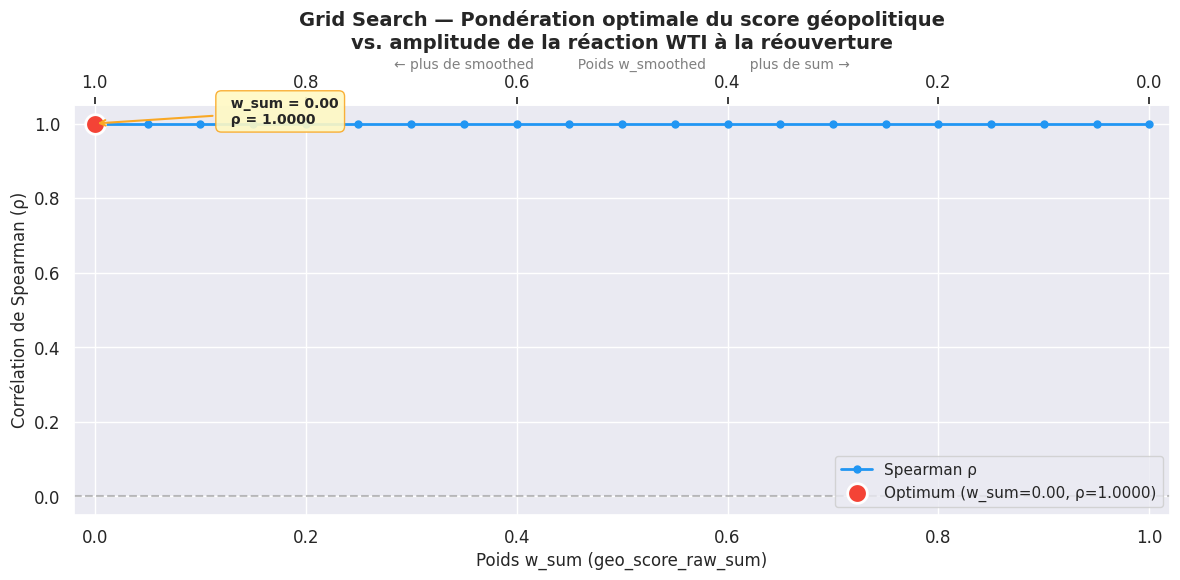

In [ ]:
# ═══════════════════════════════════════════════
# Cellule 5 — Visualisation
# ═══════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))

# Courbe de corrélation
ax.plot(
    df_results["alpha"],
    df_results["spearman_rho"],
    marker="o",
    linewidth=2,
    markersize=5,
    color="#2196F3",
    label="Spearman ρ (Variation_Pct ~ score hybride)",
    zorder=2,
)

# Point optimal
ax.scatter(
    best["alpha"],
    best["spearman_rho"],
    s=220,
    color="#F44336",
    edgecolors="white",
    linewidths=2,
    zorder=4,
    label=f"ALPHA optimal = {best['alpha']:.2f}  (ρ = {best['spearman_rho']:.4f})",
)

# Valeur actuelle hardcodée (0.8)
ax.axvline(x=0.80, color="#FF9800", linestyle="--", linewidth=1.5, alpha=0.8,
           label=f"α actuel = 0.80  (ρ = {current_alpha_rho:.4f})")

# Annotation du point optimal
offset = 0.08 if best["alpha"] < 0.85 else -0.18
ax.annotate(
    f"  α = {best['alpha']:.2f}\n  ρ = {best['spearman_rho']:.4f}",
    xy=(best["alpha"], best["spearman_rho"]),
    xytext=(best["alpha"] + offset, best["spearman_rho"]),
    fontsize=10,
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc="#FFF9C4", ec="#F9A825", alpha=0.9),
    arrowprops=dict(arrowstyle="->", color="#F9A825", lw=1.5),
)

ax.axhline(y=0, color="grey", linestyle=":", alpha=0.4)

ax.set_xlabel("ALPHA  (poids du MAX de stress)", fontsize=12)
ax.set_ylabel("Corrélation de Spearman (ρ)", fontsize=12)
ax.set_title(
    "Grid Search — Calibration de l'ALPHA du score géopolitique lissé\n"
    r"$\text{score} = \alpha \times \text{max} + (1-\alpha) \times \text{mean}$  "
    "vs.  Variation_Pct à la réouverture",
    fontsize=13,
    fontweight="bold",
)

# Axe secondaire
ax2 = ax.secondary_xaxis("top")
ax2.set_xlabel("← 100% mean           poids du MEAN           100% max →", fontsize=9, color="grey")
ticks = np.arange(0, 1.1, 0.2)
ax2.set_xticks(ticks)
ax2.set_xticklabels([f"{1-t:.1f}" for t in ticks])

ax.legend(loc="lower left", fontsize=10)
ax.set_xlim(-0.02, 1.02)
plt.tight_layout()
plt.show()